In [1]:
import pandas as pd
import numpy as np
import os
import math
import random
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("cell2cellholdout.csv", header=0)

In [14]:
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000006,NaN,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,...,0,5,No,1,150,No,5-Low,Other,Other,No
1,3000018,NaN,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,...,0,6,No,2,80,No,1-Highest,Other,Professional,No
2,3000034,NaN,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,...,0,4,No,3,10,No,3-Good,Suburban,Crafts,Yes
3,3000070,NaN,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,...,0,4,No,1,200,No,1-Highest,Other,Other,No
4,3000074,NaN,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,...,0,3,No,0,10,No,1-Highest,Suburban,Other,No


In [15]:
df.dtypes

CustomerID                     int64
Churn                        float64
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea                   object
H

In [16]:
df.shape

(20000, 58)

In [17]:
display(df.loc[[0,4], ['HandsetModels', 'AgeHH1']])

,HandsetModels,AgeHH1
0,6,30.0
4,4,58.0


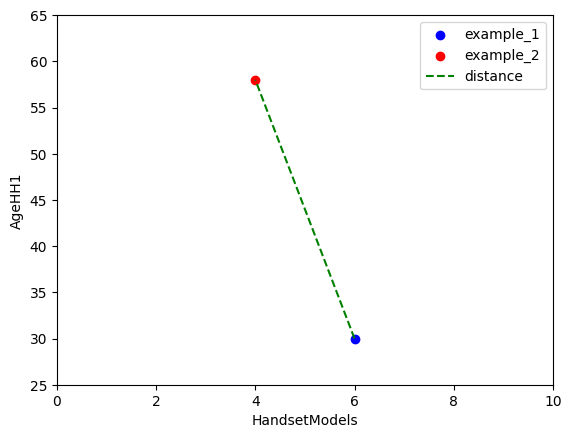

In [25]:
vector_A = [df.loc[0]['HandsetModels'], df.loc[0]['AgeHH1']]

vector_B = [df.loc[4]['HandsetModels'], df.loc[4]['AgeHH1']]

plt.scatter(vector_A[0], vector_A[1], c = 'b', label='example_1')
plt.scatter(vector_B[0], vector_B[1], c ='r', label='example_2')
plt.plot([vector_A[0], vector_B[0]], [vector_A[1], vector_B[1]], c='g', linestyle='dashed', label = 'distance')

plt.xlim([0,10])
plt.ylim([25,65])
plt.xlabel('HandsetModels')
plt.ylabel('AgeHH1')

plt.legend(loc='upper right');
plt.show()

In [24]:
euc_distance = math.sqrt((4-0)**2 + (4-6)**2)
print(euc_distance)

4.47213595499958


In [26]:
df_numerical = df.select_dtypes(include=['int64', 'float64'])

print(df_numerical.shape)
df_numerical.head()

(20000, 36)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
0,3000006,NaN,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,...,7,6,240,30.0,0.0,0,0,0,5,1
1,3000018,NaN,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,...,6,4,434,56.0,0.0,0,0,0,6,2
2,3000034,NaN,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,...,3,3,700,38.0,24.0,0,0,0,4,3
3,3000070,NaN,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,...,6,5,48,46.0,0.0,0,0,0,4,1
4,3000074,NaN,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,...,4,4,408,58.0,0.0,0,0,0,3,0


In [28]:
df_numerical = df_numerical.drop(columns=['CustomerID', 'Churn'])
df_numerical.head()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
0,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,8.3,1.0,...,7,6,240,30.0,0.0,0,0,0,5,1
1,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,9.7,0.7,...,6,4,434,56.0,0.0,0,0,0,6,2
2,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,12.7,3.0,...,3,3,700,38.0,24.0,0,0,0,4,3
3,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,2.0,0.7,...,6,5,48,46.0,0.0,0,0,0,4,1
4,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,2.7,6.0,...,4,4,408,58.0,0.0,0,0,0,3,0


In [29]:
A = df_numerical.sample(replace=False)
B = df_numerical.sample(replace=False)

In [30]:
A

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
14041,117.89,672.0,40.0,0.0,101.0,0.0,34.0,-55.5,3.3,1.0,...,1,1,349,46.0,18.0,0,0,0,4,0


In [31]:
B

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
10990,80.9,341.0,33.0,0.0,136.0,0.9,-86.0,-24.8,11.0,0.3,...,3,3,89,58.0,36.0,0,0,0,4,0


In [33]:
list_A = A.values.flatten().tolist()
list_B = B.values.flatten().tolist()

list_A

[117.89,
 672.0,
 40.0,
 0.0,
 101.0,
 0.0,
 34.0,
 -55.5,
 3.3,
 1.0,
 44.0,
 0.0,
 0.0,
 165.5,
 32.3,
 13.3,
 130.7,
 85.0,
 4.3,
 0.0,
 3.0,
 12.0,
 2.0,
 2.0,
 1.0,
 1.0,
 349.0,
 46.0,
 18.0,
 0.0,
 0.0,
 0.0,
 4.0,
 0.0]

In [36]:
list_B

[80.9,
 341.0,
 33.0,
 0.0,
 136.0,
 0.9,
 -86.0,
 -24.8,
 11.0,
 0.3,
 24.7,
 2.3,
 0.7,
 10.5,
 26.3,
 0.7,
 59.0,
 59.7,
 11.3,
 0.0,
 0.0,
 15.0,
 1.0,
 0.0,
 3.0,
 3.0,
 89.0,
 58.0,
 36.0,
 0.0,
 0.0,
 0.0,
 4.0,
 0.0]

In [34]:
def euclidean_distance(vector1, vector2):
    sum_square = 0
    numberOfIterations = len(vector1)

    for i in range(numberOfIterations):
        difference = vector2[i]-vector1[i]
        sum_square+=difference**2
    
    distance = math.sqrt(sum_square)
    return distance

In [37]:
print(round(euclidean_distance(list_A, list_B), 2))

475.53


In [38]:
array1 = np.array(A)
array2 = np.array(B)

np.linalg.norm(array2-array1)

np.float64(475.5348042993278)